## Imports

In [1]:
%load_ext autoreload
%autoreload 2

import pandas as pd
import numpy as np
from collections import OrderedDict
import matplotlib.pyplot as plt 
from sklearn.metrics import roc_curve, auc, precision_recall_curve 
import time 

import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader

from torchvision.models import resnet50, ResNet50_Weights, vit_b_32, ViT_B_32_Weights, convnext_base, ConvNeXt_Base_Weights
from torcheval.metrics import BinaryAUROC, BinaryAUPRC, BinaryAccuracy
from torch.nn.functional import softmax

from deepfake_utils.datasets import DeepFakeDataset
from deepfake_utils.models import MyModel
from deepfake_utils.train import validate_epoch

In [2]:
device = torch.device("cuda") if torch.cuda.is_available() else torch.device("cpu")

In [3]:
experiment_results = pd.read_csv("experiment_results (1).csv")
experiment_results.head()

,experiment_id,model,freeze_layers,dropout_rate,l2-penalty,optimizer,epochs,learning_rate,lr_scheduler_type,train_loss_history,...,val_pr_auc_history,val_acc_history,train_loss,train_roc_auc,train_pr_auc,train_acc,val_loss,val_roc_auc,val_pr_auc,val_acc
0,1,ConvNeXt-base-pretrained,False,0.0,0.0000,Adam,10,0.001,StepLR,"[0.7353738344632662, 0.6567150234739423, 0.598...",...,"[0.7334429025650024, 0.787969708442688, 0.8040...","[0.6095890402793884, 0.6095890402793884, 0.684...",0.066293,0.995513,0.997641,0.979487,0.904670,0.821407,0.875405,0.753425
1,2,ConvNeXt-base-pretrained,False,0.0,0.0000,Adam,10,0.001,CosineAnnealingWarmRestarts,"[0.7526439834427048, 0.6873688841040755, 0.670...",...,"[0.7147989273071289, 0.6518254280090332, 0.643...","[0.6095890402793884, 0.6095890402793884, 0.609...",0.662243,0.575213,0.659969,0.610256,0.664233,0.565395,0.643060,0.609589
2,3,ConvNeXt-base-pretrained,False,0.0,0.0001,Adam,10,0.001,StepLR,"[0.7633097861712669, 0.673798830081255, 0.6685...",...,"[0.6727218627929688, 0.6797227263450623, 0.664...","[0.6095890402793884, 0.6095890402793884, 0.609...",0.615362,0.683767,0.763509,0.650549,0.633372,0.661492,0.760451,0.633562
3,4,ConvNeXt-base-pretrained,False,0.0,0.0001,Adam,10,0.001,CosineAnnealingWarmRestarts,"[0.6939490538377028, 0.689233165084224, 0.6346...",...,"[0.7802392244338989, 0.7812657952308655, 0.819...","[0.6438356041908264, 0.6095890402793884, 0.616...",0.225595,0.973812,0.984584,0.919414,0.716488,0.780209,0.841379,0.719178
4,5,ConvNeXt-base-pretrained,False,0.2,0.0000,Adam,10,0.001,StepLR,"[0.7548039013649518, 0.6757031297509051, 0.672...",...,"[0.6685558557510376, 0.6485565900802612, 0.647...","[0.6095890402793884, 0.6095890402793884, 0.609...",0.631808,0.658815,0.739859,0.641026,0.645275,0.632121,0.706625,0.643836


In [4]:
# focus on evaluating the best model settings for each family (i.e. 1 for ResNet, 1 for ViT, 1 for ConvNeXt)
# "best" is open to redefining a bit later depending on model complexity etc. but maybe just go with highest ROC AUC on validation data for now
experiment_results.sort_values(by='val_roc_auc', ascending = False).groupby("model").first()[['experiment_id', 'val_roc_auc', 'val_pr_auc', 'val_acc', 'val_loss', 'train_roc_auc', 'train_pr_auc', 'train_acc', 'train_loss']]
# experiment_results.sort_values(by='val_roc_auc', ascending = False).groupby("model").head(3)

,experiment_id,val_roc_auc,val_pr_auc,val_acc,val_loss,train_roc_auc,train_pr_auc,train_acc,train_loss
model,,,,,,,,,
ConvNeXt-base-pretrained,1,0.821407,0.875405,0.753425,0.904670,0.995513,0.997641,0.979487,0.066293
ResNet-50-pretrained,33,0.872955,0.921372,0.770548,0.842997,0.999989,0.999993,0.998535,0.010255
ViT-b32-pretrained,26,0.785433,0.847986,0.719178,0.540543,0.865407,0.907342,0.793407,0.453412


# Bias vs. Variance (Overfitting etc.)

In [5]:
train_loss_history = eval(experiment_results.sort_values(by='val_roc_auc', ascending=False).iloc[0]['train_loss_history'])
val_loss_history = eval(experiment_results.sort_values(by='val_roc_auc', ascending=False).iloc[0]['val_loss_history'])

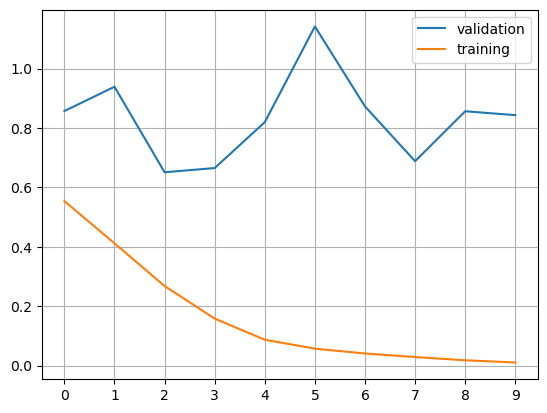

In [6]:
# if we end up showing learning curves in final report, maybe show 3 sets of train vs. val learning curves, 1 for each of the best 3 models
# see if it looks too crowded in 1 plot, or need to separate into 3 subplots side-by-side
 
plt.plot(val_loss_history, label = 'validation')
plt.plot(train_loss_history, label = 'training')
plt.xticks(np.arange(0,10,1))
plt.grid(axis = 'both')
plt.legend()
plt.show()

In [7]:
train_loss_history = eval(experiment_results.sort_values(by='val_roc_auc', ascending=False).iloc[0]['train_roc_auc_history'])
val_loss_history = eval(experiment_results.sort_values(by='val_roc_auc', ascending=False).iloc[0]['val_roc_auc_history'])

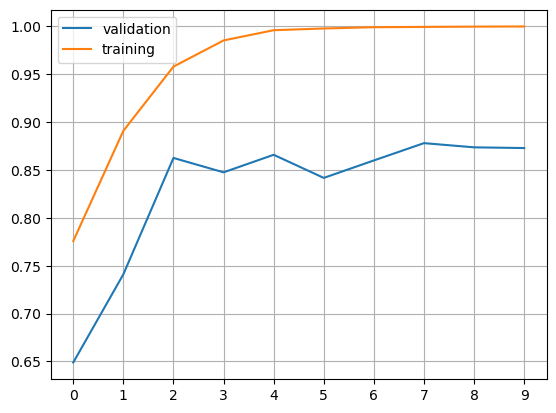

In [8]:
plt.plot(val_loss_history, label = 'validation')
plt.plot(train_loss_history, label = 'training')
plt.xticks(np.arange(0,10,1))
plt.grid(axis = 'both')
plt.legend()
plt.show()

## Evaluate Test Performance (ROC curves, precision-recall curves, tables etc.)

In [9]:
image_dir_path = 'Deepfake-Eval-2024/image-data'

In [10]:
debug_data = DeepFakeDataset("image-metadata-debug.csv", image_dir_path, model_type = 'ResNet', is_train = False)
debug_data_loader = DataLoader(debug_data, batch_size = 32, shuffle = False)

test_data = DeepFakeDataset("image-metadata-test.csv", image_dir_path, model_type = 'ResNet',  is_train = False)
test_data_loader = DataLoader(test_data, batch_size = 32, shuffle = False)
print(f"Successfully loaded {len(test_data)} samples for testing.")
print(f"Test data will be loaded in batches of {test_data_loader.batch_size}.")

Successfully loaded 293 samples for testing.
Test data will be loaded in batches of 32.


In [11]:
# maybe copy code from validate_epoch or create new utility function that returns the actual per-sample predictions so that we can plot ROC curves etc.
# this particular commit probably has tensors needed to do that
# https://github.com/Deepfake-Detection-KKO/deepfake-detection/blob/59df359e6d76043bd40df4a3fa0571ce67f79861/deepfake_utils/train.py

In [12]:
# Custom validate_epoch function to accumulate adn return all labels and probabilites for ROC-AUC and PR-AUC plots. 
def print_(message, log = True):
    if log:
        print(message)

def validate_epoch(dataloader, model, loss_fn, device, verbose = True, log_interval=5, return_preds_labels=False):
    model.eval() 
    val_loss = 0
    acc_metric = BinaryAccuracy(device=device)
    auroc_metric = BinaryAUROC(device=device)
    auprc_metric = BinaryAUPRC(device=device)

    all_labels = []
    all_probabilities = []
    
    loss_fn.reduction = 'sum' 
    
    with torch.no_grad():
        for batch, (X, y) in enumerate(dataloader):
            X = X.to(device)
            y = y.to(device)

            pred = model(X)
            val_loss += loss_fn(pred, y).item()
            
            pred_prob = softmax(pred, dim = 1)
            
            if return_preds_labels:
                all_labels.extend(y.cpu().numpy())
                all_probabilities.extend(pred_prob[:, 1].cpu().numpy())

            acc_metric.update(pred_prob[:, 1], y)
            auroc_metric.update(pred_prob[:, 1], y)
            auprc_metric.update(pred_prob[:, 1], y)
        
            if (batch + 1) % log_interval == 0 or (batch + 1) == len(dataloader):
                current = (batch + 1) * dataloader.batch_size
                print_(f"\tEvaluation Progress: \t[{current:>5d}/{len(dataloader.dataset):>5d}]", verbose)

    val_loss /= len(dataloader.dataset)
    val_acc = acc_metric.compute()
    
    if device.type == 'mps':
        results = (val_loss, float('nan'), float('nan'), val_acc.item())
    else:
        val_auroc = auroc_metric.compute()
        val_auprc = auprc_metric.compute()
        results = (val_loss, val_auroc.item(), val_auprc.item(), val_acc.item())

    if return_preds_labels:
        return (*results, np.array(all_probabilities), np.array(all_labels))
    else:
        return results
    

# Measure Inference Speed 
# Configuration 
batch_size = 32 # The batch size you want to test
image_size = (3, 224, 224) # (Channels, Height, Width) - typical for images
num_classes = 2 # Your number of output classes
batch_size_for_test = 32 # From your provided snippet for test_data_loader
batch_size_for_inference_test = 1 # Often, inference is tested with batch_size=1 for real-time latency
num_warmup_runs = 50
num_timing_runs = 500 # Number of actual runs to average over

def measure_inference_speed(model, input_tensor, device, num_warmup_runs, num_timing_runs):
    """
    Measures the average inference time of a model.

    Args:
        model (torch.nn.Module): The model to test.
        input_tensor (torch.Tensor): A dummy input tensor of the correct shape and data type.
        device (torch.device): The device (CPU, CUDA, MPS) to run inference on.
        num_warmup_runs (int): Number of initial runs to discard for warm-up.
        num_timing_runs (int): Number of runs to average for the final measurement.

    Returns:
        tuple: (avg_time_ms, std_dev_ms) - Average and standard deviation of inference time in milliseconds.
    """
    model.eval() # Set model to evaluation mode
    model.to(device) # Ensure model is on the correct device

    input_tensor = input_tensor.to(device) # Move input to device

    # Warm-up runs
    print(f"  Warming up ({num_warmup_runs} runs)...")
    with torch.no_grad():
        for _ in range(num_warmup_runs):
            _ = model(input_tensor)
            if device.type == 'cuda':
                torch.cuda.synchronize()
            elif device.type == 'mps':
                torch.mps.synchronize()

    # Actual timing runs
    print(f"  Timing inference ({num_timing_runs} runs)...")
    timings = []
    with torch.no_grad():
        for _ in range(num_timing_runs):
            if device.type == 'cuda':
                start_event = torch.cuda.Event(enable_timing=True)
                end_event = torch.cuda.Event(enable_timing=True)
                start_event.record()
                _ = model(input_tensor)
                end_event.record()
                torch.cuda.synchronize() # Ensure all CUDA operations are complete
                timings.append(start_event.elapsed_time(end_event)) # Time in milliseconds
            elif device.type == 'mps':
                # MPS events don't have .elapsed_time, use perf_counter with synchronize
                torch.mps.synchronize()
                start_time = time.perf_counter()
                _ = model(input_tensor)
                torch.mps.synchronize()
                end_time = time.perf_counter()
                timings.append((end_time - start_time) * 1000) # Convert to milliseconds
            else: # CPU
                start_time = time.perf_counter()
                _ = model(input_tensor)
                end_time = time.perf_counter()
                timings.append((end_time - start_time) * 1000) # Convert to milliseconds

    avg_time_ms = np.mean(timings)
    std_dev_ms = np.std(timings)
    return avg_time_ms, std_dev_ms



In [13]:
# Dictionary to store results for plotting 
model_results = {} # To store {'model_name': {'fpr': [], 'tpr': [], 'auc': float}}

# Adjust these paths to your actual saved model weights. Currentlt, it is hardcoded
models_to_test = {
    "ConvNeXt-base-pretrained": 'model_weights/experiment_1.pth',
    "ResNet-50-pretrained": 'model_weights/experiment_33.pth',
    "ViT-b32-pretrained": 'model_weights/experiment_26.pth',
}



--- Evaluating ConvNeXt-base-pretrained ---
Loaded weights for ConvNeXt-base-pretrained from model_weights/experiment_1.pth.
	Evaluation Progress: 	[  160/  293]
	Evaluation Progress: 	[  320/  293]

--- ConvNeXt-base-pretrained Test Results ---
Test Loss: 0.9958
Test ROC AUC: 0.8008
Test PR AUC: 0.8679
Test Accuracy: 0.7099

--- Evaluating ResNet-50-pretrained ---
Loaded weights for ResNet-50-pretrained from model_weights/experiment_33.pth.
	Evaluation Progress: 	[  160/  293]
	Evaluation Progress: 	[  320/  293]

--- ResNet-50-pretrained Test Results ---
Test Loss: 1.0059
Test ROC AUC: 0.8487
Test PR AUC: 0.9048
Test Accuracy: 0.7611

--- Evaluating ViT-b32-pretrained ---
Loaded weights for ViT-b32-pretrained from model_weights/experiment_26.pth.
	Evaluation Progress: 	[  160/  293]
	Evaluation Progress: 	[  320/  293]

--- ViT-b32-pretrained Test Results ---
Test Loss: 0.5837
Test ROC AUC: 0.7447
Test PR AUC: 0.8110
Test Accuracy: 0.7031


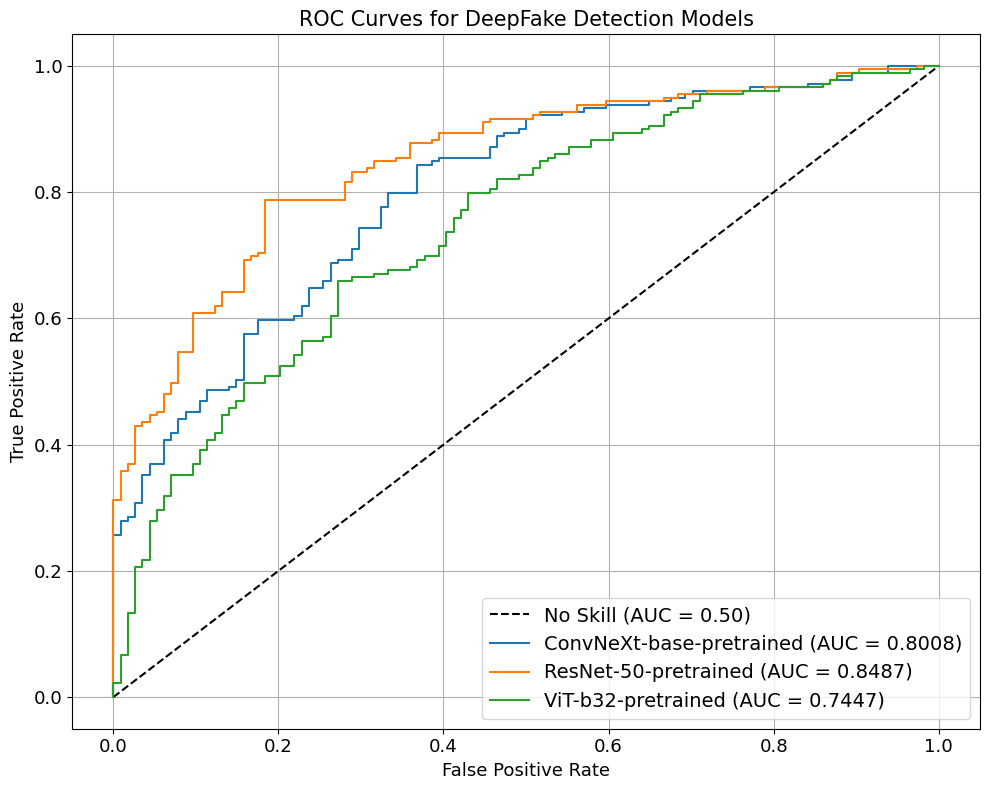

/var/folders/02/nw__lfcn0wx_1ww6266fv69m0000gn/T/ipykernel_12624/3005430449.py:116: UserWarning: linestyle is redundantly defined by the 'linestyle' keyword argument and the fmt string "k:" (-> linestyle=':'). The keyword argument will take precedence.
  plt.plot([0, 1], [positive_class_proportion, positive_class_proportion], 'k:', linestyle='--', label=f'No Skill (PR AUC = {positive_class_proportion:.2f})')


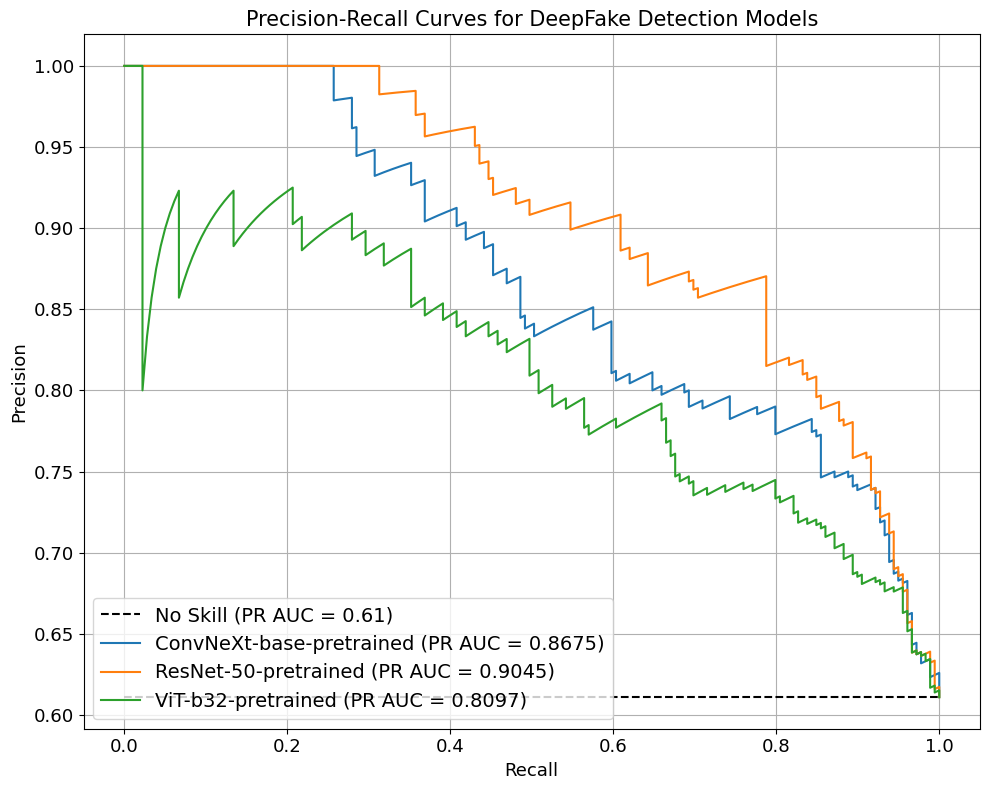

In [14]:
# Loop through each model to load, evaluate, and collect data for the ROC-AUC and PR-AUC plots
for model_name, weights_path in models_to_test.items():
    print(f"\n--- Evaluating {model_name} ---")

    # Initialize the model architecture
    current_model = MyModel(model_name, device, num_classes=2, freeze_layers=True)
    # 2. Load the specific model's weights
    try:
        current_model_weights = torch.load(weights_path, weights_only=True, map_location=device)
        # Clean the keys if "_orig_mod." prefix exists
        current_model_weights_cleaned = type(current_model_weights)([
            (k.replace("_orig_mod.", ""), v) for k, v in current_model_weights.items()
        ])
        current_model.load_state_dict(current_model_weights_cleaned)
        print(f"Loaded weights for {model_name} from {weights_path}.")
    except FileNotFoundError:
        print(f"Error: {weights_path} not found. Skipping {model_name}.")
        continue
    except Exception as e:
        print(f"Error loading state_dict for {model_name} from {weights_path}: {e}. Skipping.")
        continue

    current_model.to(device) # Ensure model is on the correct device

    # Get predictions and labels from the test set using validate_epoch
    # Pass return_preds_labels=True to get per-sample data
    # The return type depends on whether device.type == 'mps'
    results = validate_epoch(
        dataloader=test_data_loader, # Use the already loaded test_data_loader
        model=current_model,
        loss_fn=nn.CrossEntropyLoss(), # Use the same loss function
        device=device,
        verbose=True,
        return_preds_labels=True # Crucial for getting data for ROC curve
    )

    # Unpack results based on the return_preds_labels flag and MPS check
    if device.type == 'mps':
        test_loss, _, _, test_accuracy, all_probs, all_labels = results
        test_roc_auc_for_display = float('nan') # Explicitly set NaN for print
    else:
        test_loss, test_roc_auc_for_display, test_pr_auc_for_display, test_accuracy, all_probs, all_labels = results

    print(f"\n--- {model_name} Test Results ---")
    print(f"Test Loss: {test_loss:.4f}")
    # Handle printing ROC AUC/PR AUC based on MPS
    if device.type == 'mps':
        print(f"Test ROC AUC: {test_roc_auc_for_display:.4f} (Not computed on MPS)")
        print(f"Test PR AUC: {test_pr_auc_for_display:.4f} (Not computed on MPS)")
    else:
        print(f"Test ROC AUC: {test_roc_auc_for_display:.4f}")
        print(f"Test PR AUC: {test_pr_auc_for_display:.4f}")
    print(f"Test Accuracy: {test_accuracy:.4f}")

    # Calculate ROC curve from collected probabilities and labels
    fpr, tpr, _ = roc_curve(all_labels, all_probs)
    calculated_roc_auc = auc(fpr, tpr)
    
    # Calculate Precision-Recall curve
    precision, recall, _ = precision_recall_curve(all_labels, all_probs)
    calculated_pr_auc = auc(recall, precision) # Note: auc takes (x, y), so (recall, precision)

    # Store all results in model_results dictionary 
    model_results[model_name] = {
        'test_loss': test_loss,
        'test_roc_auc': test_roc_auc_for_display, # Use the displayed value (might be NaN for MPS)
        'test_pr_auc': test_pr_auc_for_display,   # Use the displayed value (might be NaN for MPS)
        'test_accuracy': test_accuracy,
        'fpr': fpr,
        'tpr': tpr,
        'roc_auc': calculated_roc_auc, # AUC calculated from fpr/tpr for plot
        'precision': precision,
        'recall': recall,
        'pr_auc': calculated_pr_auc,   # AUC calculated from precision/recall for plot
    }


# Font sizes: Adjust as needed based on visual inspection after generating
FIGURE_WIDTH = 3.25 # Inches for single column. Change to 6.875 for double column.
FIGURE_HEIGHT = FIGURE_WIDTH * 0.75 # A common aspect ratio (e.g., 4:3 or 3:2)
DPI = 300

# Font sizes (adjust these values to achieve desired readability)
FONTSIZE_TITLE = 15
FONTSIZE_LABELS = 13
FONTSIZE_TICKS = 13
FONTSIZE_LEGEND = 14 # Making this a bit larger as per your request
FONTSIZE_TEXT_ON_BARS = 10 # For the numbers on top of the bars
# Plot the ROC Curves

plt.figure(figsize=(10, 8))
plt.plot([0, 1], [0, 1], 'k--', label='No Skill (AUC = 0.50)')

for model_name, results in model_results.items():
    plt.plot(results['fpr'], results['tpr'], label=f'{model_name} (AUC = {results["roc_auc"]:.4f})')

plt.xlabel('False Positive Rate', fontsize=FONTSIZE_LABELS)
plt.ylabel('True Positive Rate', fontsize=FONTSIZE_LABELS)
plt.title('ROC Curves for DeepFake Detection Models', fontsize=FONTSIZE_TITLE)
plt.legend(loc='lower right', fontsize=FONTSIZE_LEGEND) # Increased legend fontsize
plt.grid(True)
plt.xticks(fontsize=FONTSIZE_TICKS)
plt.yticks(fontsize=FONTSIZE_TICKS)
plt.tight_layout() # Adjust layout to prevent labels from being cut off
plt.show()
# Optional: Save the figure
# plt.savefig('roc_curves.pdf', bbox_inches='tight', dpi=DPI)

# Plot the PR Curves
plt.figure(figsize=(10, 8))

# Baseline for PR curve: For a random classifier, PR AUC is the proportion of positive samples
# Calculate the positive class proportion from any set of labels (they should be the same across models)
if all_labels is not None: 
    positive_class_proportion = np.sum(all_labels) / len(all_labels)
    plt.plot([0, 1], [positive_class_proportion, positive_class_proportion], 'k:', linestyle='--', label=f'No Skill (PR AUC = {positive_class_proportion:.2f})')
else:
    # Fallback if all_labels wasn't set, e.g., due to an error earlier
    print("Warning: Could not determine positive class proportion for PR AUC baseline.")


for model_name, results in model_results.items():
    plt.plot(results['recall'], results['precision'], label=f'{model_name} (PR AUC = {results["pr_auc"]:.4f})')

plt.xlabel('Recall', fontsize=FONTSIZE_LABELS)
plt.ylabel('Precision', fontsize=FONTSIZE_LABELS)
plt.title('Precision-Recall Curves for DeepFake Detection Models', fontsize=FONTSIZE_TITLE)
plt.legend(loc='lower left', fontsize=FONTSIZE_LEGEND) # Increased legend fontsize
plt.grid(True)
plt.xticks(fontsize=FONTSIZE_TICKS)
plt.yticks(fontsize=FONTSIZE_TICKS)
plt.tight_layout()
plt.show()
# Optional: Save the figure
# plt.savefig('pr_curves.pdf', bbox_inches='tight', dpi=DPI)



In [ ]:
#  Run Inference Speed Tests
print("Running Inference Speed Tests")
# Create a dummy input tensor for inference speed test (use the shape of your actual dataset items)
# Assuming test_data_loader.dataset[0][0] gives you a sample image tensor
try:
    dummy_input_for_inference = torch.randn(batch_size_for_inference_test, *test_data_loader.dataset[0][0].shape)
    print(f"Using dummy input shape for inference speed test: {dummy_input_for_inference.shape}")
except Exception as e:
    print(f"Error creating dummy input from test_data_loader: {e}. Defaulting to (3, 224, 224).")
    dummy_input_for_inference = torch.randn(batch_size_for_inference_test, 3, 224, 224)


for model_name in models_to_test.keys():
    if model_name not in model_results:
        print(f"Skipping inference test for {model_name} (model not successfully loaded in Phase 1).")
        continue

    print(f"\nMeasuring inference speed for {model_name} (Batch Size: {batch_size_for_inference_test})...")

    # Re-initialize/load model for inference testing to ensure clean state if needed
    # Or reuse current_model if you prefer, but be careful with scope.
    # For safety, re-loading or re-initializing is often best here if Phase 1 was long ago.
    # For this structure, we assume the model_results entry exists and we can re-create model.
    model_path = models_to_test[model_name]
    current_model = MyModel(model_name, device, num_classes=num_classes, freeze_layers=True)
    try:
        loaded_weights = torch.load(model_path, weights_only=True, map_location=device)
        cleaned_weights = type(loaded_weights)([
            (k.replace("_orig_mod.", ""), v) for k, v in loaded_weights.items()
        ])
        current_model.load_state_dict(cleaned_weights)
    except Exception as e:
        print(f"Could not re-load weights for inference test for {model_name}: {e}. Skipping inference test.")
        continue # Skip this model's inference test if weights can't be loaded

    avg_ms, std_ms = measure_inference_speed(
        current_model,
        dummy_input_for_inference,
        device,
        num_warmup_runs,
        num_timing_runs
    )
    print(f"  Result: {avg_ms:.3f} ms ± {std_ms:.3f} ms")

    # Add inference results to the existing model_results entry
    model_results[model_name]['avg_inference_ms'] = avg_ms
    model_results[model_name]['std_inference_ms'] = std_ms

In [17]:
# --- NEW: Generate LaTeX Table with Inference Speed ---

# Prepare data for DataFrame
table_data = []
for model_name, results in model_results.items():
    # Use the 'test_' prefixed metrics for the table, as they come directly from validate_epoch
    # and handle MPS NaN cases.
    table_data.append({
        "Model": model_name,
        "Test Loss": results['test_loss'],
        "Test ROC AUC": results['test_roc_auc'],
        "Test PR AUC": results['test_pr_auc'],
        "Test Accuracy": results['test_accuracy'],
        # "Inference Time (ms)": f"{results['avg_inference_ms']:.3f} $\\pm$ {results['std_inference_ms']:.3f}"
    })

df_table = pd.DataFrame(table_data)

# Find the best performing model for each metric and bold it

# For Loss and Inference Time, lower is better. For AUCs and Accuracy, higher is better.
# bold_cols_numeric = ["Test Loss", "Test ROC AUC", "Test PR AUC", "Test Accuracy"]
# bold_col_inference_time = "Inference Time (ms)"

def bold_best_numeric(series, metric_name):
    numeric_series = pd.to_numeric(series, errors='coerce')
    if "Loss" in metric_name:
        best_val = numeric_series.min()
    else:
        best_val = numeric_series.max()
    return [f"\\textbf{{{x:.4f}}}" if x == best_val and not pd.isna(x) else (f"{x:.4f}" if not pd.isna(x) else "N/A") for x in numeric_series]

def bold_best_inference_time(series):
    avg_times = [float(s.split(' ')[0]) if '$\\pm$' in s else float('inf') for s in series]
    best_val_idx = np.argmin(avg_times)
    return [f"\\textbf{{{s}}}" if i == best_val_idx else s for i, s in enumerate(series)]

for col in bold_cols_numeric:
    # Ensure values are numeric before passing to bold_best_numeric
    # If they are already floats/nans from validate_epoch, this is fine
    df_table[col] = bold_best_numeric(df_table[col], col)

# # Apply bolding for inference time
# df_table[bold_col_inference_time] = bold_best_inference_time(df_table[bold_col_inference_time])

# Generate LaTeX table
latex_table = df_table.to_latex(
    index=False,
    escape=False, # Important to keep LaTeX commands like \textbf and \pm
    column_format="l||c|c|c|c|c", # Added one more 'c' for Inference Time
    caption="Comprehensive DeepFake Detection Model Performance on Test Set",
    label="tab:comprehensive_model_performance"
)

print("\n\n--- LaTeX Table with All Metrics ---")
print(latex_table)



--- LaTeX Table with All Metrics ---
\begin{table}
\caption{Comprehensive DeepFake Detection Model Performance on Test Set}
\label{tab:comprehensive_model_performance}
\begin{tabular}{l||c|c|c|c|c}
\toprule
Model & Test Loss & Test ROC AUC & Test PR AUC & Test Accuracy \\
\midrule
ConvNeXt-base-pretrained & 0.9958 & 0.8008 & 0.8679 & 0.7099 \\
ResNet-50-pretrained & 1.0059 & \textbf{0.8487} & \textbf{0.9048} & \textbf{0.7611} \\
ViT-b32-pretrained & \textbf{0.5837} & 0.7447 & 0.8110 & 0.7031 \\
\bottomrule
\end{tabular}
\end{table}

